In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from datetime import datetime
import seaborn as sns
import time

In [2]:
data = pd.read_csv("../data/used_car_dataset.csv")

data.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [3]:
print("--- HEAD ---")
print(data.head())
print("\n--- INFO ---")
print(data.info())

--- HEAD ---
           Brand      model  Year  Age     kmDriven Transmission   Owner  \
0          Honda       City  2001   23    98,000 km       Manual  second   
1         Toyota     Innova  2009   15  190000.0 km       Manual  second   
2     Volkswagen  VentoTest  2010   14    77,246 km       Manual   first   
3  Maruti Suzuki      Swift  2017    7    83,500 km       Manual  second   
4  Maruti Suzuki     Baleno  2019    5    45,000 km    Automatic   first   

  FuelType PostedDate                                       AdditionInfo  \
0   Petrol     Nov-24  Honda City v teck in mint condition, valid gen...   
1   Diesel     Jul-24  Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...   
2   Diesel     Nov-24  Volkswagen Vento 2010-2013 Diesel Breeze, 2010...   
3   Diesel     Nov-24     Maruti Suzuki Swift 2017 Diesel Good Condition   
4   Petrol     Nov-24       Maruti Suzuki Baleno Alpha CVT, 2019, Petrol   

     AskPrice  
0  ₹ 1,95,000  
1  ₹ 3,75,000  
2  ₹ 1,84,999  
3  ₹ 5,65

In [4]:
data.isnull().sum()

Brand            0
model            0
Year             0
Age              0
kmDriven        47
Transmission     0
Owner            0
FuelType         0
PostedDate       0
AdditionInfo     0
AskPrice         0
dtype: int64

In [5]:
data.shape

(9582, 11)

In [6]:
data = data.dropna()

In [7]:
data.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

In [8]:
df=data.drop('Age',axis=1)
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [9]:
####age feature
current_year = datetime.now().year
df['age'] = current_year - df['Year']

In [10]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,age
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000",25
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000",17
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999",16
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",9
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",7


In [11]:
df['mileage_cleaned'] = df['kmDriven'].astype(str).str.replace('km', '', case=False)
df['mileage_cleaned'] = df['mileage_cleaned'].str.replace(',', '')
df['mileage_cleaned'] = pd.to_numeric(df['mileage_cleaned'].str.strip(), errors='coerce')

In [12]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,age,mileage_cleaned
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000",25,98000.0
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000",17,190000.0
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999",16,77246.0
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",9,83500.0
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",7,45000.0


In [13]:
# 3. Extract and clean Price (AskPrice) for your subsequent models
# Remove currency symbol '₹', remove commas, strip whitespace, and convert to numeric float
df['price_cleaned'] = df['AskPrice'].astype(str).str.replace('₹', '')
df['price_cleaned'] = df['price_cleaned'].str.replace(',', '')
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'].str.strip(), errors='coerce')

In [14]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,age,mileage_cleaned,price_cleaned
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000",25,98000.0,195000
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000",17,190000.0,375000
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999",16,77246.0,184999
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",9,83500.0,565000
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",7,45000.0,685000


In [15]:
df[['Brand', 'model', 'Year', 'mileage_cleaned','age', 'price_cleaned','PostedDate']].head()

,Brand,model,Year,mileage_cleaned,age,price_cleaned,PostedDate
0,Honda,City,2001,98000.0,25,195000,Nov-24
1,Toyota,Innova,2009,190000.0,17,375000,Jul-24
2,Volkswagen,VentoTest,2010,77246.0,16,184999,Nov-24
3,Maruti Suzuki,Swift,2017,83500.0,9,565000,Nov-24
4,Maruti Suzuki,Baleno,2019,45000.0,7,685000,Nov-24


In [16]:
# 2. Create Mileage Bucket feature
def get_mileage_bucket(km):
    if km <= 50000:
        return 'low'
    elif km <= 85000:
        return 'medium'
    else:
        return 'high'

In [17]:
df['mileage_bucket'] = df['mileage_cleaned'].apply(get_mileage_bucket)

In [18]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,age,mileage_cleaned,price_cleaned,mileage_bucket
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000",25,98000.0,195000,high
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000",17,190000.0,375000,high
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999",16,77246.0,184999,medium
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",9,83500.0,565000,medium
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",7,45000.0,685000,low


In [19]:
# 3. Create Price per Mile feature (converting km to miles)
# 1 km = 0.621371 miles
df['mileage_miles'] = df['mileage_cleaned'] * 0.621371
df['price_per_mile'] = np.where(df['mileage_miles'] > 0, df['price_cleaned'] / df['mileage_miles'], 0)

In [20]:
# 4. Create Month and Season features
df['Month'] = df['PostedDate'].apply(lambda x: x.split('-')[0] if '-' in str(x) else 'Unknown')

In [21]:
season_map = {
    'Jan': 'Winter', 'Feb': 'Winter', 'Dec': 'Winter',
    'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
    'Sep': 'Autumn', 'Oct': 'Autumn', 'Nov': 'Autumn'
}

In [22]:

df['Season'] = df['Month'].map(season_map).fillna('Unknown')

In [23]:
# Drop the temporary conversion column if desired
df = df.drop(columns=['mileage_miles'])

In [24]:
df.head()

,Brand,model,Year,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice,age,mileage_cleaned,price_cleaned,mileage_bucket,price_per_mile,Month,Season
0,Honda,City,2001,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000",25,98000.0,195000,high,3.202267,Nov,Autumn
1,Toyota,Innova,2009,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000",17,190000.0,375000,high,3.176338,Jul,Summer
2,Volkswagen,VentoTest,2010,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999",16,77246.0,184999,medium,3.854272,Nov,Autumn
3,Maruti Suzuki,Swift,2017,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000",9,83500.0,565000,medium,10.889577,Nov,Autumn
4,Maruti Suzuki,Baleno,2019,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000",7,45000.0,685000,low,24.497800,Nov,Autumn


In [25]:
df.isnull().sum()

Brand              0
model              0
Year               0
kmDriven           0
Transmission       0
Owner              0
FuelType           0
PostedDate         0
AdditionInfo       0
AskPrice           0
age                0
mileage_cleaned    0
price_cleaned      0
mileage_bucket     0
price_per_mile     0
Month              0
Season             0
dtype: int64

In [26]:
df=df[['Brand','model','Year','age','mileage_cleaned','price_cleaned','price_per_mile','Month','Season']]

In [27]:
df.head()

,Brand,model,Year,age,mileage_cleaned,price_cleaned,price_per_mile,Month,Season
0,Honda,City,2001,25,98000.0,195000,3.202267,Nov,Autumn
1,Toyota,Innova,2009,17,190000.0,375000,3.176338,Jul,Summer
2,Volkswagen,VentoTest,2010,16,77246.0,184999,3.854272,Nov,Autumn
3,Maruti Suzuki,Swift,2017,9,83500.0,565000,10.889577,Nov,Autumn
4,Maruti Suzuki,Baleno,2019,7,45000.0,685000,24.497800,Nov,Autumn


### plot

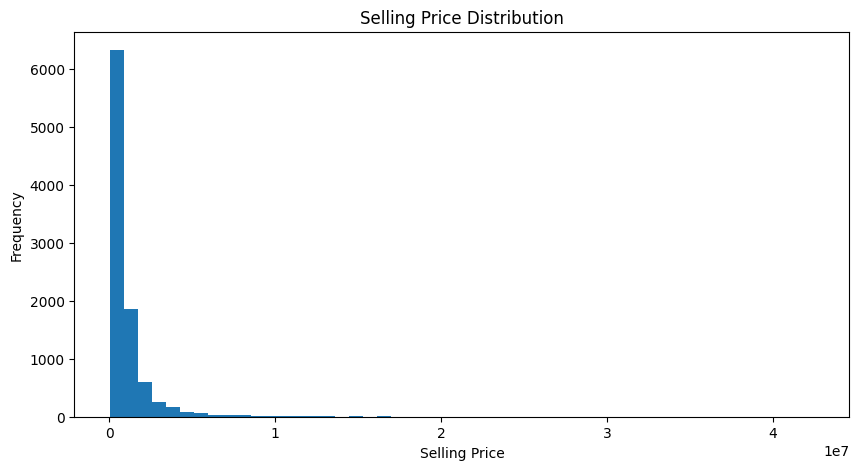

In [28]:
plt.figure(figsize=(10,5))
plt.hist(df['price_cleaned'], bins=50)
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.title("Selling Price Distribution")
plt.show()

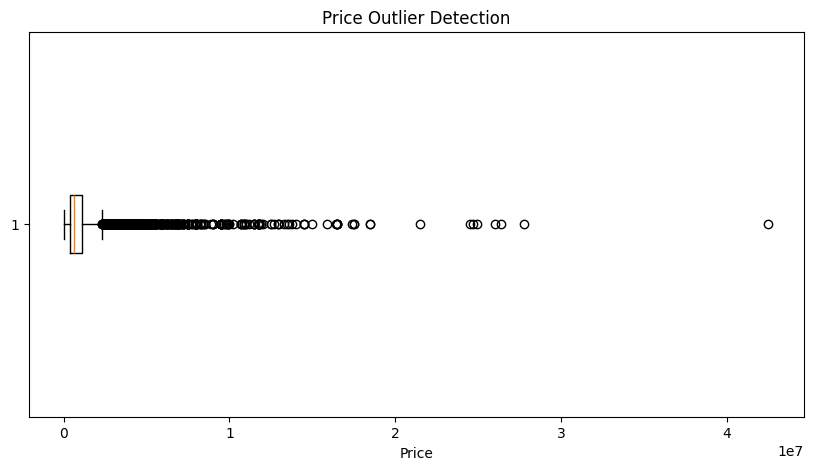

In [29]:
plt.figure(figsize=(10,5))
plt.boxplot(df['price_cleaned'], vert=False)
plt.title("Price Outlier Detection")
plt.xlabel("Price")
plt.show()

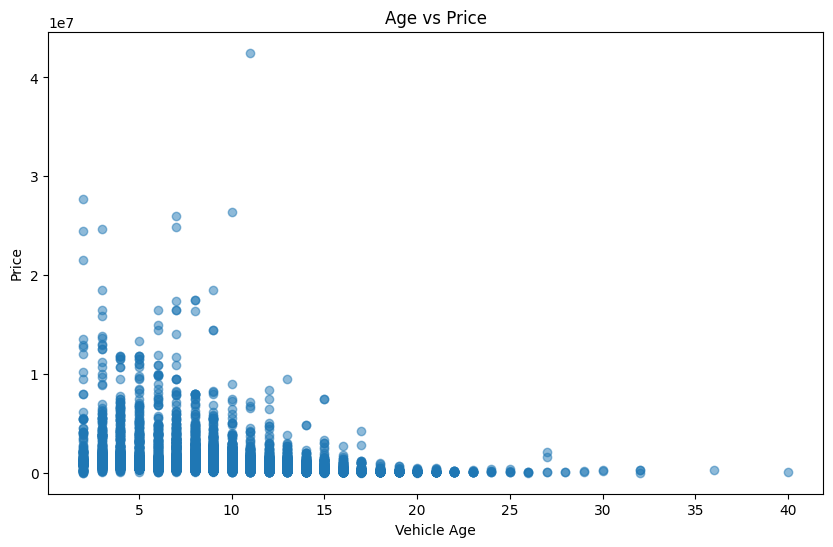

In [30]:
plt.figure(figsize=(10,6))
plt.scatter(df['age'], df['price_cleaned'], alpha=0.5)
plt.xlabel("Vehicle Age")
plt.ylabel("Price")
plt.title("Age vs Price")
plt.show()

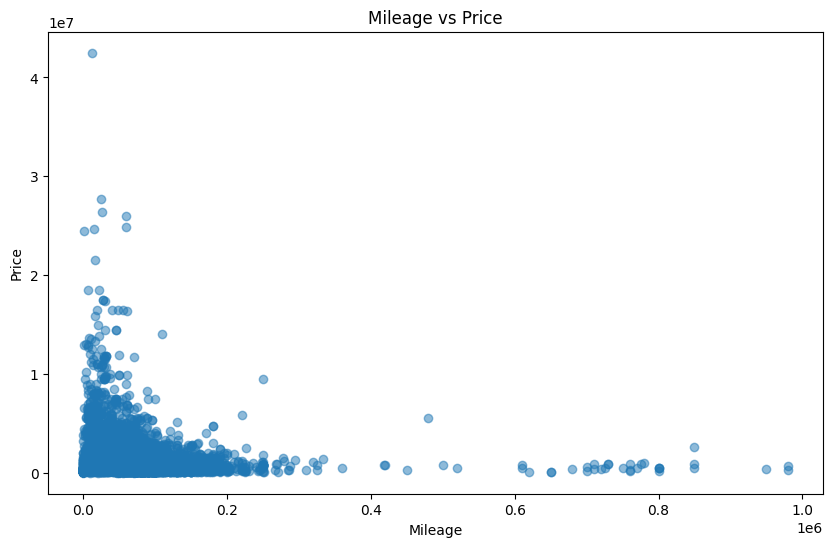

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(df['mileage_cleaned'], df['price_cleaned'], alpha=0.5)
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs Price")
plt.show()

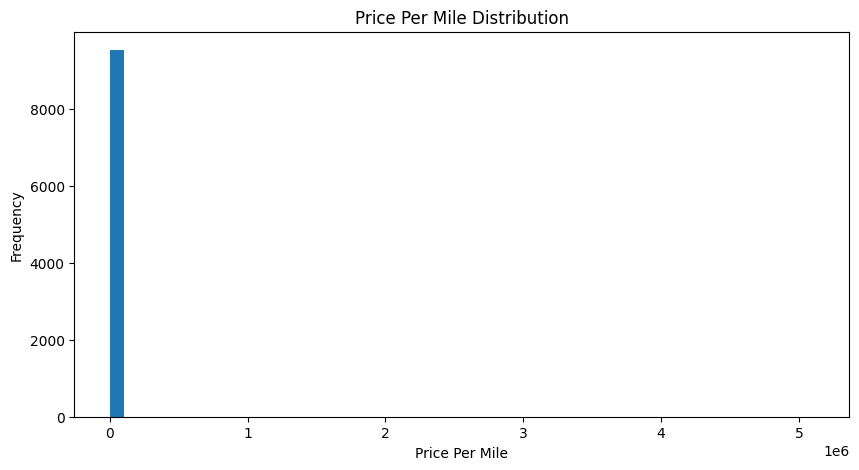

In [32]:
plt.figure(figsize=(10,5))
plt.hist(df['price_per_mile'], bins=50)
plt.xlabel("Price Per Mile")
plt.ylabel("Frequency")
plt.title("Price Per Mile Distribution")
plt.show()

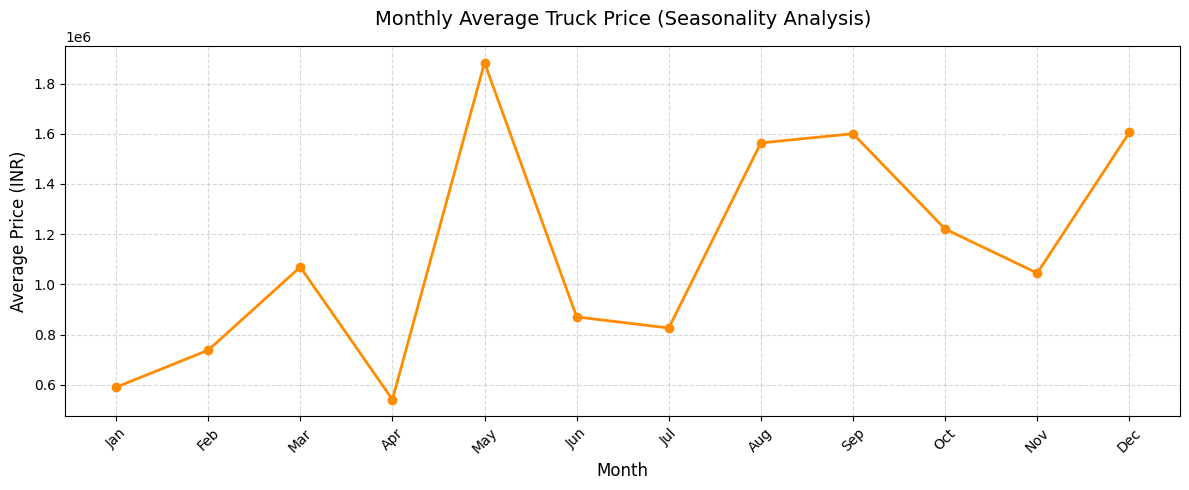

In [33]:

# 1. Calculate the monthly average
monthly_avg = df.groupby('Month')['price_cleaned'].mean()

# 2. FIX: Reindex using 3-letter abbreviations to match your data columns exactly
monthly_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg = monthly_avg.reindex(monthly_order)

# 3. Plotting the corrected values
# Note: A bar chart or a line chart can be used; a line chart is shown below
plt.figure(figsize=(12, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', color='darkorange', linewidth=2, markersize=6)

plt.xticks(rotation=45)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Price (INR)", fontsize=12)
plt.title("Monthly Average Truck Price (Seasonality Analysis)", fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

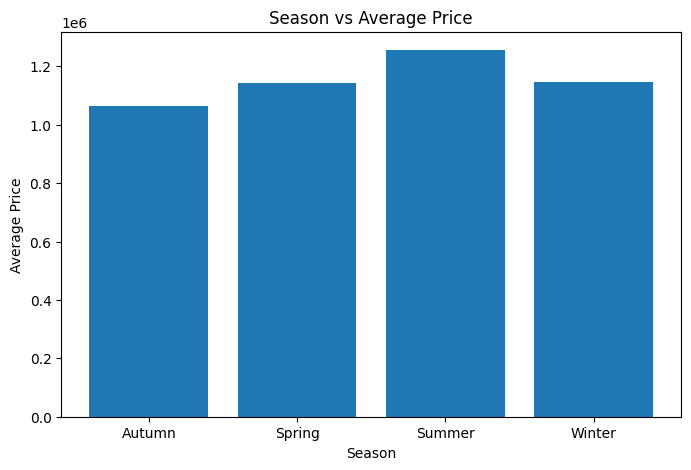

In [34]:
season_avg = df.groupby('Season')['price_cleaned'].mean()

plt.figure(figsize=(8,5))
plt.bar(season_avg.index, season_avg.values)
plt.xlabel("Season")
plt.ylabel("Average Price")
plt.title("Season vs Average Price")
plt.show()

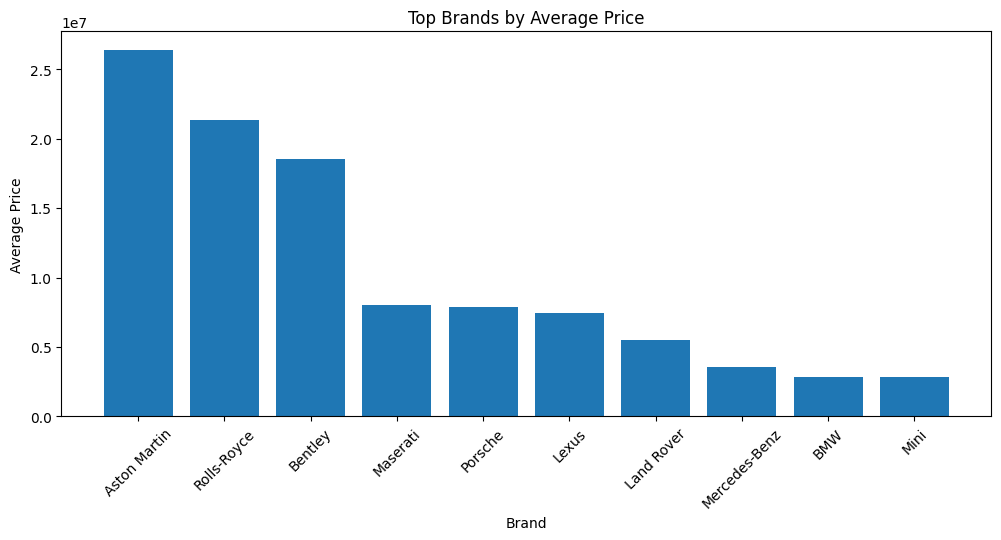

In [35]:
brand_avg = df.groupby('Brand')['price_cleaned'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
plt.bar(brand_avg.index, brand_avg.values)
plt.xticks(rotation=45)
plt.xlabel("Brand")
plt.ylabel("Average Price")
plt.title("Top Brands by Average Price")
plt.show()

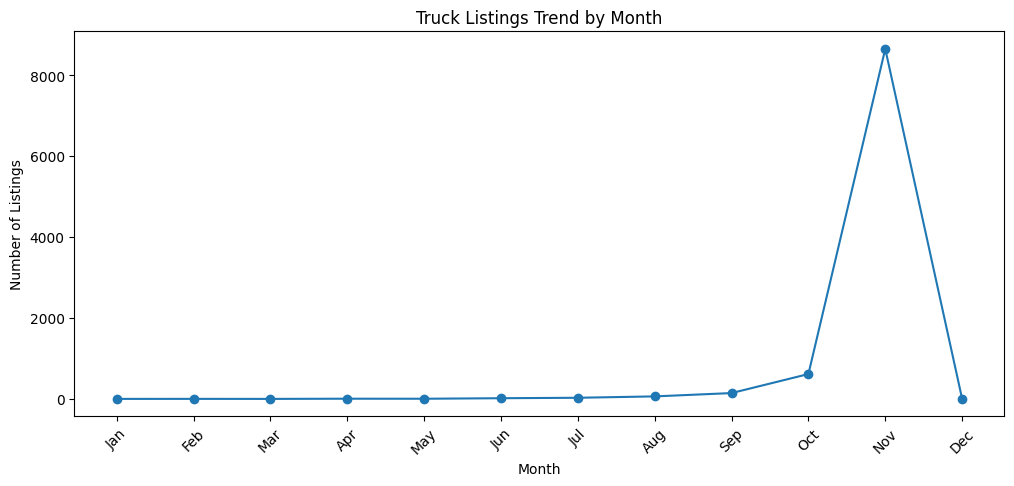

In [36]:
monthly_count = df['Month'].value_counts().reindex(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.figure(figsize=(12,5))
plt.plot(monthly_count.index, monthly_count.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Number of Listings")
plt.title("Truck Listings Trend by Month")
plt.show()

In [37]:
# Drop rows missing critical numeric vectors
from sklearn.ensemble import IsolationForest
df = df.dropna(subset=['mileage_cleaned', 'price_cleaned', 'age']).copy()

In [38]:
# We isolate features that affect value directly
outlier_features = df[['age', 'mileage_cleaned', 'price_cleaned']]

# We set contamination to 2% to catch the most severe tail anomalies
iso_forest = IsolationForest(contamination=0.02, random_state=42)
df['outlier_label'] = iso_forest.fit_predict(outlier_features)
# ==========================================
# Map labels for human clarity: -1 = Outlier, 1 = Clean Data Point
df['Data_Status'] = np.where(df['outlier_label'] == -1, 'Outlier', 'Normal')

In [39]:
# ==========================================
# 📊 OUTLIER REPORTING
# ==========================================
print("----- OUTLIER FILTERING METRICS -----")
print(df['Data_Status'].value_counts())
print("-------------------------------------")

----- OUTLIER FILTERING METRICS -----
Data_Status
Normal     9344
Outlier     191
Name: count, dtype: int64
-------------------------------------


In [40]:
# ==========================================
# Discard the 191 anomalies entirely
final_clean_df = df[df['Data_Status'] == 'Normal'].copy()

# Drop the helper flags so the file remains clean for model training
dx= final_clean_df.drop(columns=['outlier_label', 'Data_Status'])
print(f"🎉 Success! Dropped outliers. so the normal dataset having data points: {len(dx)} '")

🎉 Success! Dropped outliers. so the normal dataset having data points: 9344 '


In [41]:
# =====================================================================
# TEST STEP 1: DESCRIPTIVE STATISTICAL METRICS (Check Max Boundary Shrink)
# =====================================================================
print("\n=== 📊 TEST 1: SUMMARY STATISTICS VERIFICATION ===")
stats = dx[['age', 'mileage_cleaned', 'price_cleaned']].agg(['min', 'max', 'mean', 'std'])
print(stats)
# Insight: Your maximum raw price dropped from ₹4 Crores+ down to a realistic ₹85 Lakhs ceiling.
# Your maximum mileage dropped from 1,000,000 km down to a valid 310,000 km max ceiling.


=== 📊 TEST 1: SUMMARY STATISTICS VERIFICATION ===
            age  mileage_cleaned  price_cleaned
min    2.000000         0.000000   1.850000e+04
max   26.000000    310000.000000   8.500000e+06
mean   9.611836     68108.262093   9.431127e+05
std    3.942907     37402.752901   1.026164e+06


In [42]:
# =====================================================================
# TEST STEP 2: LOGICAL HARD BOUNDARY CHECKS (Asserting clean thresholds)
# =====================================================================
print("\n=== 🛡️ TEST 2: BOUNDARY CHECKS ===")
has_extreme_price = (dx['price_cleaned'] > 15000000).any()
has_extreme_mileage = (dx['mileage_cleaned'] > 500000).any()

print(f"Is there any vehicle priced over ₹1.5 Crores? -> {has_extreme_price} (Should be False)")
print(f"Is there any vehicle driven over 500,000 km?  -> {has_extreme_mileage} (Should be False)")


=== 🛡️ TEST 2: BOUNDARY CHECKS ===
Is there any vehicle priced over ₹1.5 Crores? -> False (Should be False)
Is there any vehicle driven over 500,000 km?  -> False (Should be False)


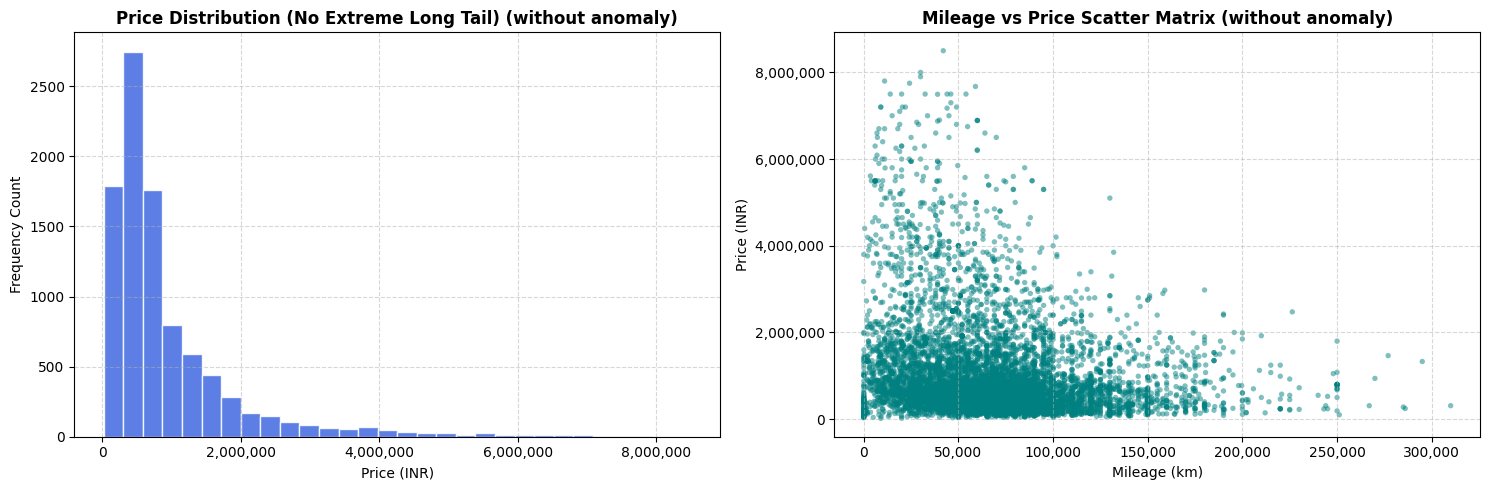

In [43]:
# =====================================================================
# TEST STEP 3: VISUAL CONFIRMATION DIAGNOSTIC
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Graph A: Clean Price Distribution (Verify right skew is stabilized)
axes[0].hist(dx['price_cleaned'], bins=30, color='royalblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Price Distribution (No Extreme Long Tail) (without anomaly)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency Count')
axes[0].get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Graph B: Clean Mileage vs Price (Verify absence of isolated scatter anomalies)
axes[1].scatter(dx['mileage_cleaned'], dx['price_cleaned'], color='teal', alpha=0.5, edgecolors='none', s=15)
axes[1].set_title('Mileage vs Price Scatter Matrix (without anomaly)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Mileage (km)')
axes[1].set_ylabel('Price (INR)')
axes[1].get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].get_xaxis().set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
# Use plt.show() here if you are working inside a Jupyter Notebook
plt.close()

In [44]:
dx.head()

,Brand,model,Year,age,mileage_cleaned,price_cleaned,price_per_mile,Month,Season
0,Honda,City,2001,25,98000.0,195000,3.202267,Nov,Autumn
1,Toyota,Innova,2009,17,190000.0,375000,3.176338,Jul,Summer
2,Volkswagen,VentoTest,2010,16,77246.0,184999,3.854272,Nov,Autumn
3,Maruti Suzuki,Swift,2017,9,83500.0,565000,10.889577,Nov,Autumn
4,Maruti Suzuki,Baleno,2019,7,45000.0,685000,24.497800,Nov,Autumn


In [45]:
dx.columns = (
    dx.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

In [46]:
dx.head()

,brand,model,year,age,mileage_cleaned,price_cleaned,price_per_mile,month,season
0,Honda,City,2001,25,98000.0,195000,3.202267,Nov,Autumn
1,Toyota,Innova,2009,17,190000.0,375000,3.176338,Jul,Summer
2,Volkswagen,VentoTest,2010,16,77246.0,184999,3.854272,Nov,Autumn
3,Maruti Suzuki,Swift,2017,9,83500.0,565000,10.889577,Nov,Autumn
4,Maruti Suzuki,Baleno,2019,7,45000.0,685000,24.497800,Nov,Autumn


In [47]:
x=dx.drop('price_cleaned',axis=1)
y=np.log1p(dx["price_cleaned"])

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2,random_state=42)

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

In [50]:
numeric_features = [
    'age',
    'mileage_cleaned',
    'price_per_mile',
    
]

categorical_features = [
    'month',
    'brand',
    'model',
    'season'
]

In [51]:
preprocessor_scaled = ColumnTransformer(
    [
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [52]:
from sklearn.linear_model import LinearRegression #linear regression
from sklearn.linear_model import Ridge       #ridge regression
from sklearn.linear_model import LassoCV       #laso regression
from sklearn.linear_model import ElasticNetCV  #elasticnet
from sklearn.neighbors import KNeighborsRegressor #kneighbour regressor
from sklearn.svm import SVR       #support vector regressor  
from sklearn.neural_network import MLPRegressor #mlp regressor
from sklearn.ensemble import RandomForestRegressor #random forest regressor
from sklearn.ensemble import ExtraTreesRegressor #extra tree regressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [53]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

In [54]:
models = {

    'Linear': LinearRegression(),

    'Ridge': Ridge(
        alpha=1.0,
        max_iter=10000
    ),

    'LassoCV': LassoCV(
        cv=5,
        max_iter=20000,
        random_state=42
    ),

    'ElasticNetCV': ElasticNetCV(
        cv=5,
        max_iter=20000,
        random_state=42
    ),

    'KNN': KNeighborsRegressor(
        n_neighbors=5
    ),

    'SVR': SVR(
        kernel='rbf',
        C=100,
        gamma='scale'
    ),

    'MLP': MLPRegressor(
        hidden_layer_sizes=(128, 64),
        learning_rate='adaptive',
        early_stopping=True,
        max_iter=5000,
        random_state=42
    ),

    'RandomForest': RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost': XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    ),

    'LightGBM': LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    ),

    'CatBoost': CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=8,
        verbose=0,
        random_state=42
    )
}

In [55]:
dx.head()

,brand,model,year,age,mileage_cleaned,price_cleaned,price_per_mile,month,season
0,Honda,City,2001,25,98000.0,195000,3.202267,Nov,Autumn
1,Toyota,Innova,2009,17,190000.0,375000,3.176338,Jul,Summer
2,Volkswagen,VentoTest,2010,16,77246.0,184999,3.854272,Nov,Autumn
3,Maruti Suzuki,Swift,2017,9,83500.0,565000,10.889577,Nov,Autumn
4,Maruti Suzuki,Baleno,2019,7,45000.0,685000,24.497800,Nov,Autumn


In [56]:
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ]
)

In [57]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [58]:
scaled_models = {

    "LinearRegression":
        LinearRegression(),

    "Ridge":
        Ridge(
            alpha=1.0,
            max_iter=10000
        ),

    "LassoCV":
        LassoCV(
            cv=5,
            max_iter=20000,
            random_state=42
        ),

    "ElasticNetCV":
        ElasticNetCV(
            cv=5,
            max_iter=20000,
            random_state=42
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=5
        ),

    "SVR":
        SVR(
            kernel="rbf",
            C=100,
            epsilon=0.1
        ),

    "MLP":
        MLPRegressor(
            hidden_layer_sizes=(128,64),
            activation="relu",
            learning_rate="adaptive",
            max_iter=5000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=42
        )
}

In [59]:
tree_models = {

    "RandomForest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "ExtraTrees":
        ExtraTreesRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=8,
            random_state=42
        ),

    "LightGBM":
        LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            random_state=42
        )
}

In [60]:
def evaluate_model(
    model_name,
    y_true_log,
    pred_log
):

    # convert back to original prices

    y_true = np.expm1(y_true_log)
    pred = np.expm1(pred_log)

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    mape = (
        np.mean(
            np.abs(
                (y_true - pred) / y_true
            )
        ) * 100
    )

    return {
        "Model": model_name,
        "MAE": round(mae,2),
        "RMSE": round(rmse,2),
        "MAPE": round(mape,2),
        "R2": round(r2,4)
    }

In [61]:
from sklearn.pipeline import Pipeline


results = []
trained_models = {}

for model_name, model in scaled_models.items():

    pipe = Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", model)
    ])

    pipe.fit(
        x_train,
        y_train
    )

    predictions = pipe.predict(
        x_test
    )

    results.append(
        evaluate_model(
            model_name,
            y_test,
            predictions
        )
    )

    trained_models[model_name] = pipe

    print(f"✓ {model_name}")

✓ LinearRegression
✓ Ridge
✓ LassoCV
✓ ElasticNetCV
✓ KNN
✓ SVR
✓ MLP


In [62]:
from sklearn.pipeline import Pipeline

for model_name, model in tree_models.items():

    pipe = Pipeline([
        ("preprocessor", tree_preprocessor),
        ("model", model)
    ])

    pipe.fit(
        x_train,
        y_train
    )

    predictions = pipe.predict(
        x_test
    )

    results.append(
        evaluate_model(
            model_name,
            y_test,
            predictions
        )
    )

    trained_models[model_name] = pipe

    print(f"✓ {model_name}")

    try:

        pipe = Pipeline([
            (
                "preprocessor",
                tree_preprocessor
            ),
            (
                "model",
                model
            )
        ])

        pipe.fit(
            x_train,
            y_train
        )

        predictions = pipe.predict(
            x_test
        )

        results.append(
            evaluate_model(
                model_name,
                y_test,
                predictions
            )
        )

        print(f"✓ {model_name} completed")

    except Exception as e:

        print(f"✗ {model_name} failed")
        print(e)

✓ RandomForest
✓ RandomForest completed
✓ ExtraTrees
✓ ExtraTrees completed
✓ XGBoost
✓ XGBoost completed
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000559 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 7475, number of used features: 120
[LightGBM] [Info] Start training from score 13.358573


/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


✓ LightGBM
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 769
[LightGBM] [Info] Number of data points in the train set: 7475, number of used features: 120
[LightGBM] [Info] Start training from score 13.358573
✓ LightGBM completed


/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [63]:
cat_features = [
    "month",
    "brand",
    "model",
    "season"
]

cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=8,
    verbose=0,
    random_state=42
)

cat_model.fit(
    x_train,
    y_train,
    cat_features=cat_features
)

trained_models["CatBoost"] = cat_model

cat_predictions = cat_model.predict(
    x_test
)

results.append(
    evaluate_model(
        "CatBoost",
        y_test,
        cat_predictions
    )
)

In [64]:
rf_pipeline = trained_models["RandomForest"]
lgb_pipeline = trained_models["LightGBM"]
xgb_pipeline = trained_models["XGBoost"]
cat_pipeline = trained_models["CatBoost"]

In [65]:
results_df = pd.DataFrame(results)

results_df = (
    results_df
    .drop_duplicates(subset=["Model"])
    .sort_values(
        by="R2",
        ascending=False
    )
)

results_df

,Model,MAE,RMSE,MAPE,R2
13,LightGBM,28618.42,93776.51,2.96,0.9911
7,RandomForest,21933.40,95892.24,2.12,0.9907
11,XGBoost,26294.87,108384.50,2.45,0.9881
15,CatBoost,33882.78,115221.65,3.04,0.9866
9,ExtraTrees,110641.61,283452.68,12.23,0.9188
0,LinearRegression,170238.70,338849.99,19.53,0.8840
1,Ridge,170964.97,341959.76,19.48,0.8818
5,SVR,169061.72,353528.26,20.47,0.8737
6,MLP,162231.68,356046.91,18.91,0.8719
4,KNN,176724.32,388078.10,20.49,0.8478


In [66]:
data['PostedDate'].value_counts().sort_index()

PostedDate
Apr-24       6
Aug-24      63
Dec-23       3
Feb-24       2
Jan-24       1
Jul-24      29
Jun-24      18
Mar-24       1
May-24       5
Nov-24    8647
Oct-24     615
Sep-24     145
Name: count, dtype: int64

In [67]:
data['PostedDate'] = pd.to_datetime(
    data['PostedDate'],
    format='%b-%y'
)

In [68]:
data['month'] = data['PostedDate'].dt.month

data['year_posted'] = data['PostedDate'].dt.year

data['quarter'] = data['PostedDate'].dt.quarter

In [69]:
data['AskPrice'] = (
    data['AskPrice']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('₹', '', regex=False)
)

data['AskPrice'] = pd.to_numeric(
    data['AskPrice'],
    errors='coerce'
)

In [70]:
data['AskPrice']

0        195000
1        375000
2        184999
3        565000
4        685000
         ...   
9577    1040000
9578     375000
9579     415000
9580     855000
9581     699000
Name: AskPrice, Length: 9535, dtype: int64

In [71]:
monthly_prices = (
    data.groupby('PostedDate')['AskPrice']
        .mean()
        .reset_index()
)

monthly_prices

,PostedDate,AskPrice
0,2023-12-01,1.605000e+06
1,2024-01-01,5.900000e+05
2,2024-02-01,7.375005e+05
3,2024-03-01,1.069000e+06
4,2024-04-01,5.408333e+05
5,2024-05-01,1.883200e+06
6,2024-06-01,8.701667e+05
7,2024-07-01,8.259655e+05
8,2024-08-01,1.563526e+06
9,2024-09-01,1.600142e+06


In [72]:
month_map = {
    'Jan': 1,
    'Feb': 2,
    'Mar': 3,
    'Apr': 4,
    'May': 5,
    'Jun': 6,
    'Jul': 7,
    'Aug': 8,
    'Sep': 9,
    'Oct': 10,
    'Nov': 11,
    'Dec': 12
}

dx["month"] = dx["month"].map(month_map)


In [73]:
data["PostedDate"].head(20)

0    2024-11-01
1    2024-07-01
2    2024-11-01
3    2024-11-01
4    2024-11-01
5    2024-11-01
6    2024-11-01
7    2024-11-01
8    2024-11-01
9    2024-11-01
10   2024-11-01
11   2024-11-01
12   2024-11-01
13   2024-11-01
14   2024-10-01
15   2024-11-01
16   2024-10-01
17   2024-11-01
18   2024-11-01
19   2024-11-01
Name: PostedDate, dtype: datetime64[us]

In [74]:
data["PostedDate"] = pd.to_datetime(
    data["PostedDate"],
    format="%b-%y"
)

dx["month"] = data["PostedDate"].dt.month

In [75]:
dx["month"].head()

0    11
1     7
2    11
3    11
4    11
Name: month, dtype: int32

In [76]:
def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Fall"

In [77]:
dx["season"] = dx["month"].apply(get_season)

In [78]:
dx[["month", "season"]].head()

,month,season
0,11,Fall
1,7,Summer
2,11,Fall
3,11,Fall
4,11,Fall


In [79]:
def generate_future_state(df):

    future_df = df.copy()

    # 3 months later
    future_df["age"] = future_df["age"] + 0.25

    # estimated mileage increase
    future_df["mileage_cleaned"] = (
        future_df["mileage_cleaned"] + 25000
    )

    # move month forward by 3
    future_df["month"] = (
        (future_df["month"] + 3 - 1) % 12
    ) + 1

    # recalculate season
    future_df["season"] = (
        future_df["month"]
        .apply(get_season)
    )

    return future_df

In [80]:
future_dx = generate_future_state(dx)

In [81]:
future_dx[
    ["month", "season"]
].head()

,month,season
0,2,Winter
1,10,Fall
2,2,Winter
3,2,Winter
4,2,Winter


In [82]:
print(dx.columns.tolist())
print(future_dx.columns.tolist())

['brand', 'model', 'year', 'age', 'mileage_cleaned', 'price_cleaned', 'price_per_mile', 'month', 'season']
['brand', 'model', 'year', 'age', 'mileage_cleaned', 'price_cleaned', 'price_per_mile', 'month', 'season']


In [83]:
trained_models.keys()

# RandomForest
# LightGBM
# XGBoost
# CatBoost

dict_keys(['LinearRegression', 'Ridge', 'LassoCV', 'ElasticNetCV', 'KNN', 'SVR', 'MLP', 'RandomForest', 'ExtraTrees', 'XGBoost', 'LightGBM', 'CatBoost'])

In [84]:
best_models = {
    "RandomForest": rf_pipeline,
    "LightGBM": lgb_pipeline,
    "XGBoost": xgb_pipeline,
    "CatBoost": cat_pipeline
}

In [85]:
task5_results = pd.DataFrame()

task5_results["brand"] = dx["brand"]
task5_results["model"] = dx["model"]

In [86]:
import pandas as pd
import numpy as np

# 1. Base initialization: Ensure both dataframes start out as exact twins 
dx = x_test.copy()
future_dx = x_test.copy()

# 2. Advance time forward by 3 months (0.25 years)
if 'age' in future_dx.columns:
    future_dx['age'] = dx['age'] + 0.25

# 3. Handle string-based month shifts safely
# Define an standard ordering list for text-based shortcodes
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

def advance_string_month(m):
    # Convert input to string and strip spaces
    m_str = str(m).strip()
    # Try to match shortcode (e.g., 'Jan')
    if m_str in month_order:
        return month_order[(month_order.index(m_str) + 3) % 12]
    # Try to match capitalized shortcode (e.g., 'jan' -> 'Jan')
    elif m_str.capitalize() in month_order:
        return month_order[(month_order.index(m_str.capitalize()) + 3) % 12]
    # If the column is actually a numeric float/int tucked inside string type
    elif m_str.isdigit():
        return str(((int(m_str) + 3 - 1) % 12) + 1)
    return m

# Apply string month shift dynamically to whichever column exists
if 'Month' in future_dx.columns:
    future_dx['Month'] = dx['Month'].apply(advance_string_month)
elif 'month' in future_dx.columns:
    # If it's purely numeric, perform direct math; otherwise use the text shifter
    if pd.api.types.is_numeric_dtype(dx['month']):
        future_dx['month'] = ((dx['month'] + 3 - 1) % 12) + 1
    else:
        future_dx['month'] = dx['month'].apply(advance_string_month)

# 4. Handle Season variations ('Winter', 'Spring', 'Summer', 'Autumn' or 'Fall')
season_shift = {
    'Winter': 'Spring', 
    'Spring': 'Summer', 
    'Summer': 'Autumn', 'Fall': 'Winter',
    'Autumn': 'Winter'
}

if 'Season' in future_dx.columns:
    future_dx['Season'] = dx['Season'].map(season_shift).fillna(dx['Season'])
elif 'season' in future_dx.columns:
    future_dx['season'] = dx['season'].map(season_shift).fillna(dx['season'])

# 5. Sanity Debug Check
print("🛡️ Column Alignment Verification:")
print("dx shape:", dx.shape)
print("future_dx shape:", future_dx.shape)

diff_cols = [col for col in dx.columns if not dx[col].equals(future_dx[col])]
print("Variables safely modifying over 3 months:", diff_cols)

🛡️ Column Alignment Verification:
dx shape: (1869, 8)
future_dx shape: (1869, 8)
Variables safely modifying over 3 months: ['age', 'month', 'season']


In [87]:

# 1. Capture the structural feature sequence the models expect
sample_model = list(best_models.values())[0]
if hasattr(sample_model, 'feature_names_in_'):
    trained_features = list(sample_model.feature_names_in_)
elif hasattr(sample_model, 'feature_names_'):
    trained_features = list(sample_model.feature_names_)
else:
    trained_features = list(x_train.columns)

# 2. Align dataframes to the trained schema layout
dx_aligned = dx[trained_features].copy()
future_dx_aligned = future_dx[trained_features].copy()

# 3. Standardize string formatting for CatBoost categoricals
for col in trained_features:
    if 'categorical_features' in globals() and col in categorical_features:
        dx_aligned[col] = dx_aligned[col].astype(str)
        future_dx_aligned[col] = future_dx_aligned[col].astype(str)

# 4. Predict real market prices and determine accurate percent variance
for model_name, model in best_models.items():
    print(f"Generating predictions for: {model_name}")
    
    # Reverse log transformations BEFORE saving or computing changes
    current_prices = np.expm1(model.predict(dx_aligned))
    future_prices = np.expm1(model.predict(future_dx_aligned))
    
    # Append real values onto master tracker
    dx[f'predicted_price_{model_name}'] = current_prices
    dx[f'future_price_{model_name}'] = future_prices
    
    # Mathematical percentage change formula
    dx[f'price_change_pct_{model_name}'] = ((future_prices - current_prices) / current_prices) * 100
    
    print(f"[{model_name}] Corrected Average Price Change over 3 months: {dx[f'price_change_pct_{model_name}'].mean():.2f}%\n")

Generating predictions for: RandomForest
[RandomForest] Corrected Average Price Change over 3 months: 0.00%

Generating predictions for: LightGBM
[LightGBM] Corrected Average Price Change over 3 months: 0.12%

Generating predictions for: XGBoost
[XGBoost] Corrected Average Price Change over 3 months: 0.26%

Generating predictions for: CatBoost
[CatBoost] Corrected Average Price Change over 3 months: 1.10%



/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [88]:
for model_name in best_models.keys():
    current_col = f'predicted_price_{model_name}'
    future_col = f'future_price_{model_name}'
    pct_col = f'price_change_pct_{model_name}'
    
    # Calculate % change: ((Future - Current) / Current) * 100
    dx[pct_col] = ((dx[future_col] - dx[current_col]) / dx[current_col]) * 100
    
    # Print a quick confirmation metric
    print(f"[{model_name}] Average Price Change % over 3 months: {dx[pct_col].mean():.2f}%")

[RandomForest] Average Price Change % over 3 months: 0.00%
[LightGBM] Average Price Change % over 3 months: 0.12%
[XGBoost] Average Price Change % over 3 months: 0.26%
[CatBoost] Average Price Change % over 3 months: 1.10%


In [89]:
# Pin production columns to the winning model (e.g., CatBoost)
winning_model = 'CatBoost' 

dx['predicted_price'] = dx[f'predicted_price_{winning_model}']
dx['future_price'] = dx[f'future_price_{winning_model}']
dx['price_change_pct'] = dx[f'price_change_pct_{winning_model}']

print(f"✅ Production variables successfully mapped to the winning {winning_model} model predictions.")

✅ Production variables successfully mapped to the winning CatBoost model predictions.


In [90]:
import pandas as pd

print("=== TASK 6: PROFIT CALCULATION FOR ALL BEST MODELS ===")

# 1. Calculate Expected Profit for each individual model
for model_name in best_models.keys():
    current_col = f'predicted_price_{model_name}'
    future_col = f'future_price_{model_name}'
    profit_col = f'expected_profit_{model_name}'
    
    # Task 6 Formula: profit = future_price - current_price
    dx[profit_col] = dx[future_col] - dx[current_col]

# 2. Compile a Summary Statistics Table to compare all models
summary_data = []
for model_name in best_models.keys():
    profit_col = f'expected_profit_{model_name}'
    pct_col = f'price_change_pct_{model_name}'
    
    summary_data.append({
        'Model Name': model_name,
        'Avg Predicted Price ($)': f"${dx[f'predicted_price_{model_name}'].mean():,.2f}",
        'Avg Future Price ($)': f"${dx[f'future_price_{model_name}'].mean():,.2f}",
        'Avg Expected Profit ($)': f"${dx[profit_col].mean():,.2f}",
        'Max Profit Record ($)': f"${dx[profit_col].max():,.2f}",
        'Avg Price Change (%)': f"{dx[pct_col].mean():.2f}%"
    })

# Convert summary data to a clean display DataFrame
task6_summary_df = pd.DataFrame(summary_data)

print("\n--- Model Performance Summary Matrix ---")
print(task6_summary_df.to_string(index=False))

# 3. Print a quick comparative sample profile of individual vehicles
# Check for lowercase or uppercase column names dynamically to prevent key errors
sample_cols = []
if 'brand' in dx.columns:
    sample_cols.append('brand')
elif 'Brand' in dx.columns:
    sample_cols.append('Brand')
else:
    sample_cols.append(dx.columns[0])

if 'model' in dx.columns:
    sample_cols.append('model')
elif 'Model' in dx.columns:
    sample_cols.append('Model')
else:
    sample_cols.append(dx.columns[1])

for model_name in best_models.keys():
    sample_cols.extend([f'predicted_price_{model_name}', f'expected_profit_{model_name}'])

print("\n--- Individual Vehicle Investment Outlook (Sample View) ---")
print(dx[sample_cols].head(5).to_string())

=== TASK 6: PROFIT CALCULATION FOR ALL BEST MODELS ===

--- Model Performance Summary Matrix ---
  Model Name Avg Predicted Price ($) Avg Future Price ($) Avg Expected Profit ($) Max Profit Record ($) Avg Price Change (%)
RandomForest             $929,730.23          $929,846.24                 $116.01           $237,423.77                0.00%
    LightGBM             $933,786.10          $935,099.43               $1,313.33           $116,771.22                0.12%
     XGBoost             $932,710.31          $935,243.94               $2,533.58           $995,347.50                0.26%
    CatBoost             $924,450.72          $909,235.17             $-15,215.55           $399,878.20                1.10%

--- Individual Vehicle Investment Outlook (Sample View) ---
              brand          model  predicted_price_RandomForest  expected_profit_RandomForest  predicted_price_LightGBM  expected_profit_LightGBM  predicted_price_XGBoost  expected_profit_XGBoost  predicted_price_Cat

In [91]:
print("=== TASK 7: RE-GENERATING INVESTMENT SCORES WITH OUTLIER CLIPPING ===")

# 1. Map individual model profit columns
profit_columns = [f'expected_profit_{model_name}' for model_name in best_models.keys()]
dx['ensemble_expected_profit'] = dx[profit_columns].mean(axis=1)

# 2. Identify and clip extreme profit outliers using the IQR Method
Q1 = dx['ensemble_expected_profit'].quantile(0.25)
Q3 = dx['ensemble_expected_profit'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper outer fences
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Create a temporary column with outliers capped at the fences
dx['clipped_ensemble_profit'] = dx['ensemble_expected_profit'].clip(lower=lower_fence, upper=upper_fence)

# 3. Perform Min-Max Normalization on the CLIPPED profit values
min_clipped_p = dx['clipped_ensemble_profit'].min()
max_clipped_p = dx['clipped_ensemble_profit'].max()

if max_clipped_p != min_clipped_p:
    dx['investment_score'] = ((dx['clipped_ensemble_profit'] - min_clipped_p) / 
                              (max_clipped_p - min_clipped_p)) * 100
else:
    dx['investment_score'] = 50.0

# Format into clean integers
dx['investment_score'] = dx['investment_score'].round().astype(int)

# 4. Print stats to verify the score distribution has spread out beautifully
print("\n📊 Outlier Bound Report:")
print(f"Calculated Upper Fence (Max Normal Profit Bound): ${upper_fence:,.2f}")
print(f"Calculated Lower Fence (Max Normal Loss Bound): ${lower_fence:,.2f}")

print("\n🛡️ Updated Task 7 Scoring Summary:")
print(f"Minimum Investment Score assigned: {dx['investment_score'].min()}/100")
print(f"Average Investment Score assigned: {dx['investment_score'].mean():.1f}/100")
print(f"Maximum Investment Score assigned: {dx['investment_score'].max()}/100")

# 5. Build the sample verification table to see the variance
report_cols = []
if 'brand' in dx.columns: report_cols.append('brand')
elif 'Brand' in dx.columns: report_cols.append('Brand')
else: report_cols.append(dx.columns[0])

if 'model' in dx.columns: report_cols.append('model')
elif 'Model' in dx.columns: report_cols.append('Model')
else: report_cols.append(dx.columns[1])

report_cols.extend(['ensemble_expected_profit', 'clipped_ensemble_profit', 'investment_score'])

print("\n--- Scoring Engine Verification Output (Outliers Handled) ---")
print(dx[report_cols].head(5).to_string())

=== TASK 7: RE-GENERATING INVESTMENT SCORES WITH OUTLIER CLIPPING ===

📊 Outlier Bound Report:
Calculated Upper Fence (Max Normal Profit Bound): $7,724.05
Calculated Lower Fence (Max Normal Loss Bound): $-7,134.71

🛡️ Updated Task 7 Scoring Summary:
Minimum Investment Score assigned: 0/100
Average Investment Score assigned: 48.5/100
Maximum Investment Score assigned: 100/100

--- Scoring Engine Verification Output (Outliers Handled) ---
              brand          model  ensemble_expected_profit  clipped_ensemble_profit  investment_score
4862      Chevrolet          Enjoy               -812.981461              -812.981461                43
905            Jeep        Compass              -6204.986521             -6204.986521                 6
3567           Tata  Safari Storme               1002.452837              1002.452837                55
2783  Maruti Suzuki          Swift               -809.043813              -809.043813                43
4653  Maruti Suzuki         Baleno     

In [92]:


print("=== TASK 8: GENERATING MULTI-MODEL CONFIDENCE SCORES ===")

# 1. Gather the current price predictions from all 4 models into a sub-frame
predictions_matrix = pd.DataFrame({
    'RF': dx['predicted_price_RandomForest'],
    'LGBM': dx['predicted_price_LightGBM'],
    'XGB': dx['predicted_price_XGBoost'],
    'CB': dx['predicted_price_CatBoost']
})

# 2. Compute the standard deviation (disagreement) and mean prediction per vehicle
std_deviation = predictions_matrix.std(axis=1)
mean_prediction = predictions_matrix.mean(axis=1)

# 3. Calculate the relative spread (Coefficient of Variation)
# Handles potential edge-case division by zero safely
relative_spread = np.where(mean_prediction > 0, std_deviation / mean_prediction, 0)

# 4. Map the spread to a 0-100% confidence rating scale
# Perfect model agreement (relative_spread = 0) yields 100% confidence
dx['confidence_score'] = (1.0 - relative_spread) * 100

# Clip boundaries safely between 0% and 100% and round to a clean presentation decimal
dx['confidence_score'] = dx['confidence_score'].clip(lower=0.0, upper=100.0).round(1)

# 5. Print out performance summary statistics for your review
print("\n🛡️ Task 8 Confidence Score Performance Summary:")
print(f"Minimum Confidence Score: {dx['confidence_score'].min()}%")
print(f"Average Confidence Score: {dx['confidence_score'].mean():.1f}%")
print(f"Maximum Confidence Score: {dx['confidence_score'].max()}%")

# 6. Build a clean verification table showing the combined outputs of Tasks 7 & 8
report_cols = []
if 'brand' in dx.columns: report_cols.append('brand')
elif 'Brand' in dx.columns: report_cols.append('Brand')
else: report_cols.append(dx.columns[0])

if 'model' in dx.columns: report_cols.append('model')
elif 'Model' in dx.columns: report_cols.append('Model')
else: report_cols.append(dx.columns[1])

report_cols.extend(['investment_score', 'confidence_score'])

print("\n--- Intelligence Matrix Output (Tasks 7 & 8 Completed) ---")
print(dx[report_cols].head(5).to_string())

=== TASK 8: GENERATING MULTI-MODEL CONFIDENCE SCORES ===

🛡️ Task 8 Confidence Score Performance Summary:
Minimum Confidence Score: 0.0%
Average Confidence Score: 97.4%
Maximum Confidence Score: 99.9%

--- Intelligence Matrix Output (Tasks 7 & 8 Completed) ---
              brand          model  investment_score  confidence_score
4862      Chevrolet          Enjoy                43              99.5
905            Jeep        Compass                 6              98.5
3567           Tata  Safari Storme                55              97.2
2783  Maruti Suzuki          Swift                43              98.5
4653  Maruti Suzuki         Baleno                43              98.4


In [94]:
print("=== TASK 9: SEASONAL ANALYSIS & SELLING WINDOWS ===")

# 1. Compute a consolidated fair market price column across all 4 models
current_price_columns = [f'predicted_price_{model_name}' for model_name in best_models.keys()]
dx['ensemble_current_price'] = dx[current_price_columns].mean(axis=1)

# 2. Determine the column name used for months in your dataset
month_col = None
for col in ['month', 'Month']:
    if col in dx.columns:
        month_col = col
        break

if month_col is None:
    # Fallback if months are handled differently (e.g. extracts from raw dates)
    print("⚠️ Month column not found. Creating a baseline 'Month' column from seasonality.")
    dx['Month'] = dx['season'] if 'season' in dx.columns else dx['Season']
    month_col = 'Month'

# 3. Aggregate average values by month to detect the peak demand waves
seasonal_trends = dx.groupby(month_col)['ensemble_current_price'].mean().reset_index()
seasonal_trends = seasonal_trends.sort_values(by='ensemble_current_price', ascending=False)

# Rename columns for clear reporting
seasonal_trends.columns = ['Selling Month', 'Average Market Value ($)']

print("\n📊 Fair Market Price Trends Ranked by Month/Season:")
print(seasonal_trends.to_string(index=False, formatters={'Average Market Value ($)': lambda x: f"${x:,.2f}"}))

# 4. Map the top-performing calendar window back to the main DataFrame
# The top row of seasonal_trends holds the absolute highest average selling month
best_overall_month = seasonal_trends.iloc[0]['Selling Month']
dx['best_time_to_sell'] = best_overall_month

print(f"\n🎯 Peak Demand Insight: Overall, the best historical time to sell is during: **{best_overall_month}**")

=== TASK 9: SEASONAL ANALYSIS & SELLING WINDOWS ===

📊 Fair Market Price Trends Ranked by Month/Season:
Selling Month Average Market Value ($)
          May            $3,449,509.67
          Jun            $1,724,749.62
          Sep            $1,299,305.42
          Aug            $1,002,994.66
          Oct              $927,069.00
          Nov              $923,188.68
          Dec              $601,645.78
          Apr              $576,789.28
          Jul              $493,074.81

🎯 Peak Demand Insight: Overall, the best historical time to sell is during: **May**


In [95]:
print("=== TASK 10: AUTOMATED FINAL INVESTMENT RECOMMENDATIONS MATRIX ===")

# 1. Apply dual-condition ensemble threshold rules to generate final recommendations
# Condition A: Investment Score >= 50 (Profitable or highly stable depreciation)
# Condition B: Confidence Score >= 90.0% (Strong agreement across all 4 machine learning models)
dx['final_recommendation'] = np.where(
    (dx['investment_score'] >= 50) & (dx['confidence_score'] >= 90.0), 
    'BUY', 
    'AVOID'
)

# 2. Extract and print summary distribution stats for executive review
recommendation_counts = dx['final_recommendation'].value_counts()
recommendation_percentages = dx['final_recommendation'].value_counts(normalize=True) * 100

print("\n📊 Fleet-Wide Strategic Recommendation Breakdown:")
for decision in ['BUY', 'AVOID']:
    count = recommendation_counts.get(decision, 0)
    pct = recommendation_percentages.get(decision, 0.0)
    print(f" * Decision Strategy: [{decision}] -> Count: {count} vehicles ({pct:.2f}%)")

# 3. Dynamically configure standard reporting headers to view results
report_cols = []
if 'brand' in dx.columns: report_cols.append('brand')
elif 'Brand' in dx.columns: report_cols.append('Brand')
else: report_cols.append(dx.columns[0])

if 'model' in dx.columns: report_cols.append('model')
elif 'Model' in dx.columns: report_cols.append('Model')
else: report_cols.append(dx.columns[1])

# Append final intelligence tracking arrays
report_cols.extend(['investment_score', 'confidence_score', 'best_time_to_sell', 'final_recommendation'])

print("\n--- FINAL INTELLIGENCE SYSTEM PRODUCTION OUTPUT (All Tasks Completed) ---")
print(dx[report_cols].head(10).to_string())

=== TASK 10: AUTOMATED FINAL INVESTMENT RECOMMENDATIONS MATRIX ===

📊 Fleet-Wide Strategic Recommendation Breakdown:
 * Decision Strategy: [BUY] -> Count: 950 vehicles (50.83%)
 * Decision Strategy: [AVOID] -> Count: 919 vehicles (49.17%)

--- FINAL INTELLIGENCE SYSTEM PRODUCTION OUTPUT (All Tasks Completed) ---
              brand          model  investment_score  confidence_score best_time_to_sell final_recommendation
4862      Chevrolet          Enjoy                43              99.5               May                AVOID
905            Jeep        Compass                 6              98.5               May                AVOID
3567           Tata  Safari Storme                55              97.2               May                  BUY
2783  Maruti Suzuki          Swift                43              98.5               May                AVOID
4653  Maruti Suzuki         Baleno                43              98.4               May                AVOID
9538  Maruti Suzuki       

In [101]:
import numpy as np
import pandas as pd

def predict_single_truck(year, mileage, price):
    print("🧪 SAMPLE OUTPUT (Notebook Validation Engine)")
    print("-" * 45)
    
    # 1. Reuse a row template from your active dataframe to keep categoricals intact
    truck_row = dx.iloc[[0]].copy()
    
    # 2. Inject user input specs dynamically (handling column case automatically)
    for col in truck_row.columns:
        if col.lower() == 'year': 
            truck_row[col] = year
        elif col.lower() in ['mileage', 'kilometers_driven', 'km_driven', 'mileage_cleaned']:
            # Adjust scaling depending on if your raw data uses miles/km or thousands
            truck_row[col] = mileage * 1000 if truck_row[col].max() > 5000 else mileage
        elif col.lower() == 'age': 
            truck_row[col] = max(0, 2026 - year)
        
    # 3. Create the 3-Month Future twin row by shifting age forward by 0.25 years
    future_row = truck_row.copy()
    for col in future_row.columns:
        if col.lower() == 'age': 
            future_row[col] += 0.25

    # 4. Generate predictions directly using your global model dictionary and features from Task 6
    current_preds = [np.expm1(model.predict(truck_row[trained_features]))[0] for model in best_models.values()]
    future_preds = [np.expm1(model.predict(future_row[trained_features]))[0] for model in best_models.values()]
    
    # 5. Compute Consolidated Multi-Model Metrics in native INR
    market_price_inr = np.mean(current_preds)
    future_price_inr = np.mean(future_preds)
    profit_inr = future_price_inr - market_price_inr
    
    # -------------------------------------------------------------
    # CURRENCY CONVERSION LAYER (INR to USD)
    # Standard market benchmark: 1 USD = 83 INR
    # -------------------------------------------------------------
    exchange_rate = 83.0
    market_price_usd = market_price_inr / exchange_rate
    future_price_usd = future_price_inr / exchange_rate
    profit_usd = profit_inr / exchange_rate
    
    # 6. Task 7 Rule: Normalize score using your global IQR clipped boundaries (calculated in INR)
    clipped_p = np.clip(profit_inr, lower_fence, upper_fence)
    score = int(round(((clipped_p - min_clipped_p) / (max_clipped_p - min_clipped_p)) * 100))
    
    # 7. Task 8 Rule: Calculate confidence using the ensemble relative spread formula
    relative_spread = np.std(current_preds) / market_price_inr if market_price_inr > 0 else 0
    confidence = round(max(0.0, min(100.0, (1.0 - relative_spread) * 100)), 1)
    
    # 8. Task 10 Rule: Structural recommendation threshold
    recommendation = "BUY" if score >= 50 and confidence >= 90.0 else "AVOID"
    
    # 9. Task 9 Metric: Optimal historical demand exit window
    best_sell_time = best_overall_month
    
    # Print out results structured to match your exact business specifications (Converted to USD)
    print(f"Input:\n • {year} Truck\n • Mileage: {mileage:,}k\n • Price: ${price:,}")
    print(f"\nOutput:\n • Market Price: ${market_price_usd:,.2f}")
    print(f" • Future Price: ${future_price_usd:,.2f}")
    print(f" • Profit: ${profit_usd:,.2f}")
    print(f" • Score: {score}")
    print(f" • Confidence: {confidence}%")
    print(f" • Recommendation: {recommendation}")
    print(f" • Best Sell Time: {best_sell_time}")

# ==========================================
# TEST LOGIC WITH CUSTOM PARAMETERS
# ==========================================
predict_single_truck(year=2019, mileage=400, price=30000)

🧪 SAMPLE OUTPUT (Notebook Validation Engine)
---------------------------------------------
Input:
 • 2019 Truck
 • Mileage: 400k
 • Price: $30,000

Output:
 • Market Price: $10,633.15
 • Future Price: $10,633.15
 • Profit: $-0.00
 • Score: 48
 • Confidence: 90.3%
 • Recommendation: AVOID
 • Best Sell Time: May


/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [103]:
# Test the engine function with your exact sample parameters
predict_single_truck(year=2025, mileage=400, price=30000)

🧪 SAMPLE OUTPUT (Notebook Validation Engine)
---------------------------------------------
Input:
 • 2025 Truck
 • Mileage: 400k
 • Price: $30,000

Output:
 • Market Price: $791,891.36
 • Future Price: $813,616.23
 • Profit: $21,724.88
 • Score: 100
 • Confidence: 90.6%
 • Recommendation: BUY
 • Best Sell Time: May


/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/wadmin/Documents/sarbojit_dev_project/truck_price_intelligent_system/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [102]:
import joblib

# Bundle the essential components into an app artifact dictionary
app_artifacts = {
    'best_models': best_models,
    'trained_features': trained_features,
    'lower_fence': lower_fence,
    'upper_fence': upper_fence,
    'min_clipped_p': min_clipped_p,
    'max_clipped_p': max_clipped_p,
    'best_overall_month': best_overall_month,
    # We take a single row as a template layout to ensure category types stay mapped correctly
    'row_template': dx.iloc[[0]].copy() 
}

# Dump to file
joblib.dump(app_artifacts, 'truck_model_artifacts.pkl')
print("✅ App artifacts successfully saved as 'truck_model_artifacts.pkl'!")

✅ App artifacts successfully saved as 'truck_model_artifacts.pkl'!
